In [7]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("..")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [8]:
# read from json
flow_num = 3
datas = [None] * flow_num
experiment_names = []
experiment_names += ["dcqcn-1-9-100-5-15-a5", "poseidon-1-9-100-5-15-m005","hpcc-1-9-100-5-15"]
for i in range(len(datas)):
    with open("../../../output/oscar-nsdi26/experiments/fig1/" + experiment_names[i] + ".json", "r") as f:
        datas[i] = json.load(f)

In [9]:
send_rate_interval_ns = 25e3
flow_num = 1
send_rate = []
headers = [54, 54 + 12, 54 + 42, 54 + 42]
for d in range(len(datas)):
    data = datas[d]
    send_rate.append([])
    wnd_start = data["flowStatistics"][0]["sentPkt"][0]["timeNs"]
    # the first point
    send_rate[d].append({"timeNs": wnd_start, "sendRateGbps": 0})
    wnd_data = 0
    pkt_idxs = [0 for _ in range(flow_num)]
    while True:
        wnd_data = 0
        next_wnd_start = wnd_start + send_rate_interval_ns
        for i in range(flow_num):
            pkt_idx = 0
            for pkt_idx in range(pkt_idxs[i], len(data["flowStatistics"][i]["sentPkt"])):
                sentPkt = data["flowStatistics"][i]["sentPkt"][pkt_idx]
                if sentPkt["timeNs"] - wnd_start > send_rate_interval_ns:
                    # Gbps = bpns
                    # pkt_idxs[i] = pkt_idx - 1
                    break
                wnd_data += sentPkt["sizeByte"] + headers[d]
            pkt_idxs[i] = pkt_idx
        send_rate[d].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                            "sendRateGbps": wnd_data * 8 / send_rate_interval_ns})
        wnd_start = next_wnd_start

        should_break = True
        for i in range(flow_num):
            if pkt_idxs[i] < len(data["flowStatistics"][i]["sentPkt"]) - 1:
                should_break = False
                break
        if should_break:
            break
    # the last point
    send_rate[d].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                        "sendRateGbps": 0})



In [10]:
for i in range(flow_num):
    # pre-process the rate to make the plot's line correct
    for j in range(1, len(datas[i]["flowStatistics"][0]["ccStats"]["rate"])):
        if datas[i]["flowStatistics"][0]["ccStats"]["rate"][j]["rateBitps"] != datas[i]["flowStatistics"][0]["ccStats"]["rate"][j-1]["rateBitps"]:
            datas[i]["flowStatistics"][0]["ccStats"]["rate"].insert(j, {"timeNs": datas[i]["flowStatistics"][0]["ccStats"]["rate"][j]["timeNs"],
                                                                        "rateBitps": datas[i]["flowStatistics"][0]["ccStats"]["rate"][j-1]["rateBitps"]})
            j += 1

In [11]:
i = 1  # poseidon
# scale the rate of poseidon to fix its target scaling
scale = 2.3
time_shift = 100e3
for j in range(1, len(datas[i]["flowStatistics"][0]["ccStats"]["rate"])):
    if datas[i]["flowStatistics"][0]["ccStats"]["rate"][j]["timeNs"]/1e3 - time_shift < 5000 and \
       datas[i]["flowStatistics"][0]["ccStats"]["rate"][j]["timeNs"]/1e3 - time_shift > 1024:
        datas[i]["flowStatistics"][0]["ccStats"]["rate"][j]["rateBitps"] /= scale


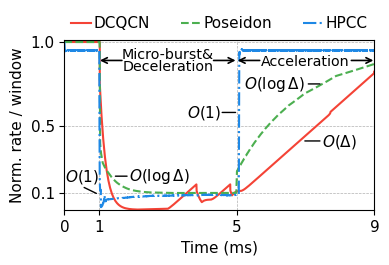

In [12]:
# draw the send rate in a new figure
fig = plt.figure(figsize=(4, 2.2))
ax = fig.add_subplot(111)
ax.set_xlabel("Time (ms)", fontsize=11)
ax.set_ylabel("Norm. rate / window", fontsize=11)
y_scale = 1/100
y_data_scale = [1/100, 1/100, 1/100]
x_scale = 1/1e3

legend_lines = []
labels = ["DCQCN", "Poseidon", "HPCC"]

color_rate = ["#F44336", "#4CAF50", "#1E88E5", "#FFC107"]
color_queue = ["#4E342E", "#FB8C00"]
line = ["-", "--", "-.", "-"]

time_shifts = [100e3] * 4
data_map = [0, 1, 2]
for i in range(len(data_map)):
    lline = ax.plot([(r["timeNs"]/1e3 - time_shifts[data_map[i]])*x_scale for r in datas[data_map[i]]["flowStatistics"][0]["ccStats"]["rate"]], 
                    [r["rateBitps"]/1e9*y_data_scale[i] for r in datas[data_map[i]]["flowStatistics"][0]["ccStats"]["rate"]], 
                    label="flow"+str(i), color=color_rate[i], linestyle=line[i])
    legend_lines.append(lline[0])
ax.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax.annotate('', xy=(500*x_scale,14*y_scale), xytext=(1000*x_scale,9*y_scale), arrowprops=dict(arrowstyle='-', lw=1))
ax.text(500*x_scale, 17*y_scale, s=f'$O(1)$', fontsize=11, ha='center')
ax.annotate('', xy=(1900*x_scale,20*y_scale), xytext=(1400*x_scale,20*y_scale), arrowprops=dict(arrowstyle='-', lw=1))
ax.text(2750*x_scale, 17*y_scale, s=f'$O(\log\Delta)$', fontsize=11, ha='center')

ax.annotate('', xy=(4500*x_scale,58*y_scale), xytext=(5050*x_scale,58*y_scale), arrowprops=dict(arrowstyle='-', lw=1))
ax.text(4050*x_scale, 55*y_scale, s=f'$O(1)$', fontsize=11, ha='center')
ax.annotate('', xy=(7000*x_scale,75*y_scale), xytext=(7500*x_scale,75*y_scale), arrowprops=dict(arrowstyle='-', lw=1))
ax.text(6100*x_scale, 72*y_scale, s=f'$O(\log\Delta)$', fontsize=11, ha='center')
ax.annotate('', xy=(7500*x_scale,41*y_scale), xytext=(6900*x_scale,41*y_scale), arrowprops=dict(arrowstyle='-', lw=1))
ax.text(8000*x_scale, 38*y_scale, s=f'$O(\Delta)$', fontsize=11, ha='center')

ax.annotate('', xy=(5050*x_scale,89*y_scale), xytext=(4250*x_scale,89*y_scale), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(950*x_scale,89*y_scale), xytext=(1750*x_scale,89*y_scale), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.text(3000*x_scale, 83*y_scale, s=f'Deceleration', fontsize=10.3, ha='center')
ax.text(3000*x_scale, 90*y_scale, s=f'Micro-burst&', fontsize=10.3, ha='center')

ax.annotate('', xy=(8250*x_scale,89*y_scale), xytext=(9050*x_scale,89*y_scale), arrowprops=dict(arrowstyle='<-', lw=1.2))
ax.annotate('', xy=(4950*x_scale,89*y_scale), xytext=(5750*x_scale,89*y_scale), arrowprops=dict(arrowstyle='->', lw=1.2))
ax.text(7000*x_scale, 86*y_scale, s=f'Acceleration', fontsize=10.3, ha='center')

ax.set_xlim(0, 9000*x_scale)
ax.set_xticks([0, 1, 5, 9])
ax.set_ylim(0, 101*y_scale)
ax.set_yticks([10*y_scale, 50*y_scale, 100*y_scale])

# set ticks fontsize
ax.tick_params(axis='both', which='major', labelsize=11)

ax.legend(legend_lines, labels, loc='center', fontsize=11, 
          frameon=False, fancybox=False, bbox_to_anchor=(0.5, 1.1), labelspacing=0.2, handletextpad=0.2, handlelength=1.3,
          ncol = 3)

plt.savefig("../figures/fig1.pdf", bbox_inches='tight', dpi=600, format='pdf')